      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape (rows, cols): (15, 9)

Datatype of each column:
 name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary Statistics:
             math    science 

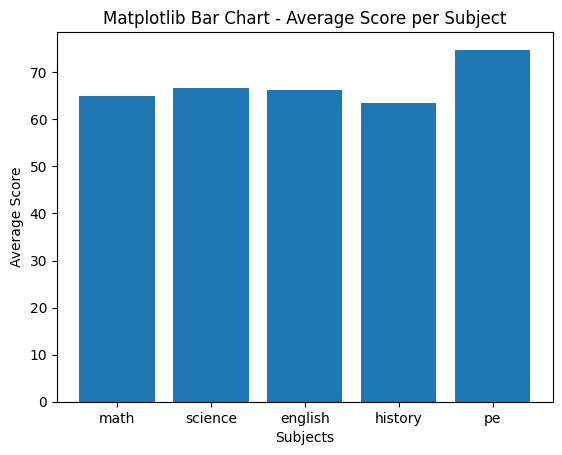

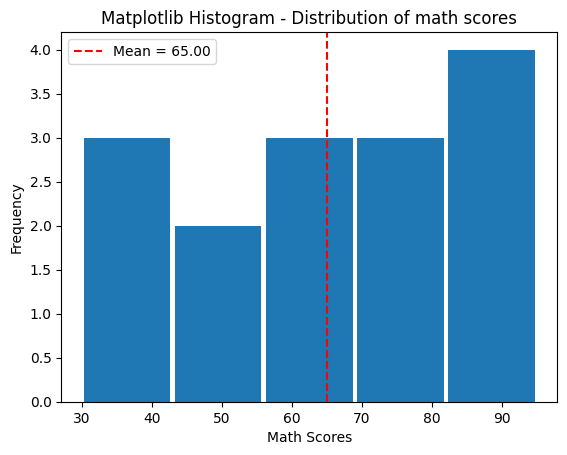

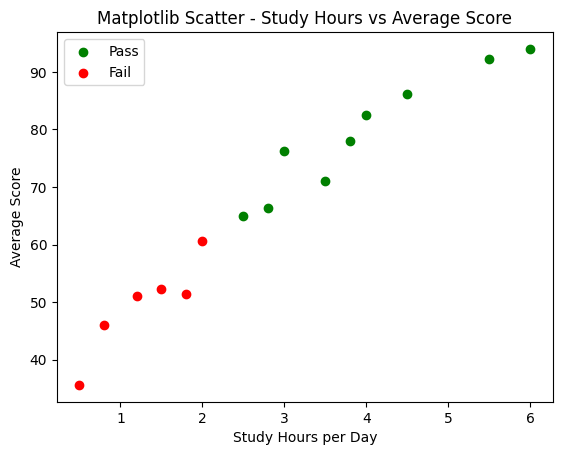

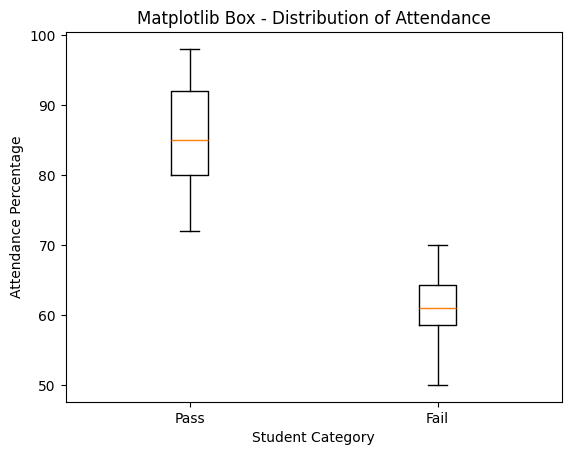

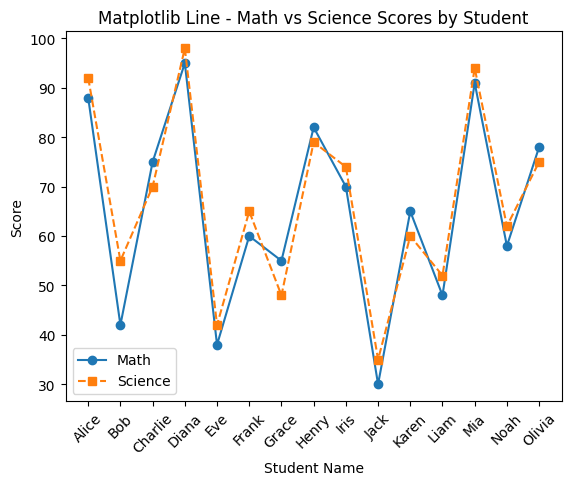

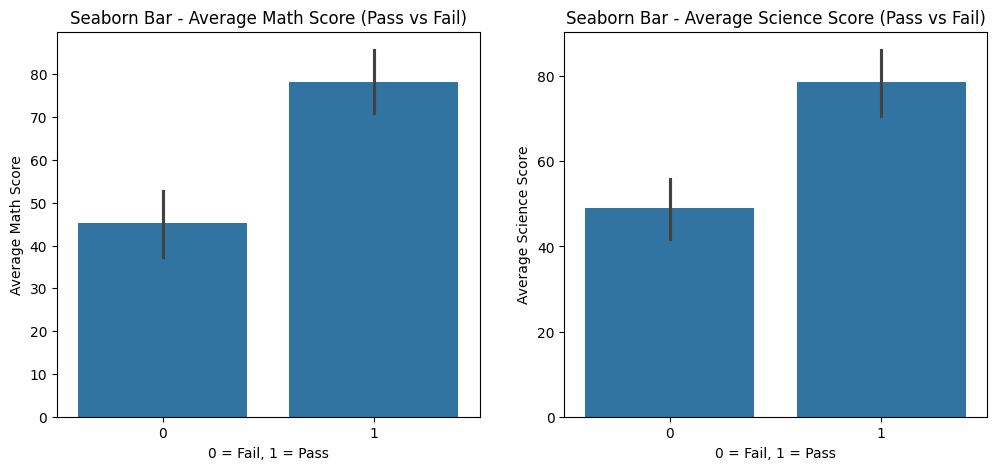

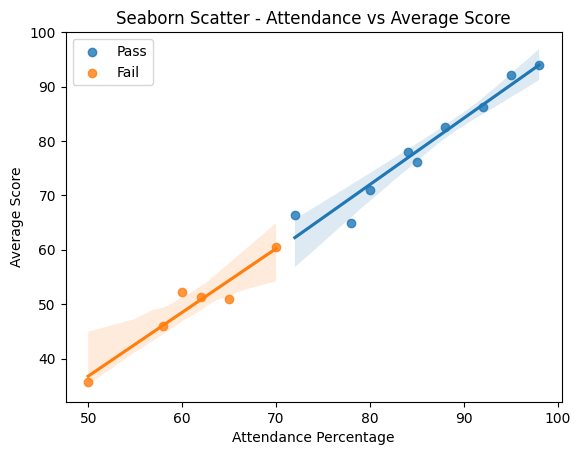

Training Accuracy: 1.00
Test Accuracy: 1.00

Student-wise Predictions:

Jack: Actual=0, Predicted=0 → ✅ Correct
Liam: Actual=0, Predicted=0 → ✅ Correct
Alice: Actual=1, Predicted=1 → ✅ Correct


               feature  coefficient
2              english     0.812513
5       attendance_pct     0.521876
6  study_hours_per_day     0.484433
4                   pe     0.474974
0                 math     0.437944
1              science     0.323010
3              history     0.262929


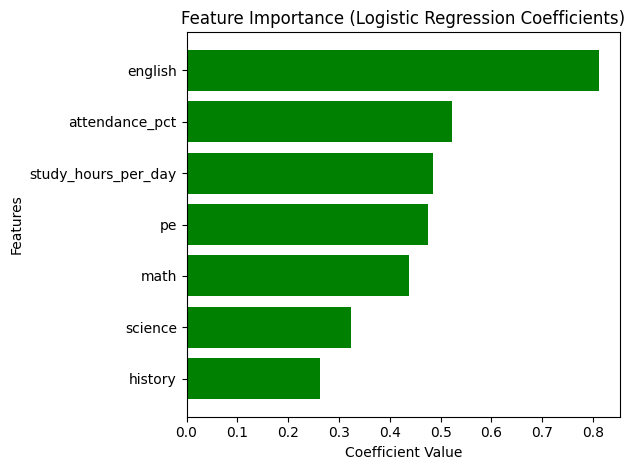

Prediction: Pass
Probability (Pass): 0.91
Probability (Fail): 0.09


In [1]:
### Theme: Student Performance Analysis & Prediction

# Task 1 — Data Exploration with Pandas

import pandas as pd

# Loading the dataset
df = pd.read_csv("students.csv");

# 1.Printing first 5 rows
print(df.head(5))

# 2.Printing shape and datatype of each column
print("\nShape (rows, cols):", df.shape)
print("\nDatatype of each column:\n",df.dtypes)


# 3.Printing summary statistics 
print("\nSummary Statistics:\n",df.describe())

# 4. Printing the count of students who passed and who failed.
counts = df["passed"].value_counts()
print(f"\nNo of students who passed: {counts.get(1, 0)}")
print(f"No of students who failed: {counts.get(0, 0)}")

# 5. Computing and printing the average score per subject

# Define Subject Columns
subject_cols = ['math', 'science', 'english', 'history', 'pe']

# Average scores for passed students
passed_avg = df[df['passed'] == 1][subject_cols].mean()

# Average scores for failed students
failed_avg = df[df['passed'] == 0][subject_cols].mean()

# Print results
print("\nAverage scores (Passed Students):")
print(passed_avg.round(2))

print("\nAverage scores (Failed Students):")
print(failed_avg.round(2))

# 6. Finding and printing the student with the highest overall average across all 5 subjects.

#Creating a temporary average column
df['avg_score'] = df[subject_cols].mean(axis=1)

#Finding the student with highest average
top_student = df.loc[df['avg_score'].idxmax()]

#Priting the student with the highest overall average
print(f"\nStudent with highest overall average score: {top_student['name']}")
print(f"Highest average score: {top_student['avg_score']:.2f}")

# Task 2 — Data Visualization with Matplotlib
import matplotlib.pyplot as plt

subject_cols = ['math', 'science', 'english', 'history', 'pe']

df['avg_score'] = df[subject_cols].mean(axis=1)

print(df['avg_score'])

# 1. Bar Chart

plt.figure()

# Compute average per subject 
avg_scores = df[subject_cols].mean()

# Create bar chart
plt.bar(subject_cols,avg_scores.values, label = 'Average Score')

# Labels and title
plt.title("Matplotlib Bar Chart - Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

# Save plot
plt.savefig("plot1_bar.png")

# Show plot
plt.show()

# 2.  Histogram 

plt.figure()
plt.hist(df['math'], bins=5, rwidth = 0.95)
mean_math_score = df['math'].mean()
plt.axvline(x=mean_math_score, linestyle='--', label = f'Mean = {mean_math_score:.2f}', color = 'red',)
plt.title('Matplotlib Histogram - Distribution of math scores')
plt.xlabel('Math Scores')
plt.ylabel('Frequency')
plt.legend()

# Save plot
plt.savefig("plot2_hist.png")

plt.show()

# 3. Scatter Plot

# Separate passed and failed students data
passed_df = df[df['passed'] == 1]
failed_df = df[df['passed'] == 0]

plt.figure()

# Scatter for passed students
plt.scatter(
passed_df['study_hours_per_day'],
passed_df['avg_score'],
color = 'green',
label = 'Pass')

# Scatter for failed students
plt.scatter(
failed_df['study_hours_per_day'],
failed_df['avg_score'],
color = 'red',
label = 'Fail')

plt.title('Matplotlib Scatter - Study Hours vs Average Score')
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

# Save and show
plt.savefig("plot3_scatter.png")
plt.show()


# 4. Box Plot

# Extract attendance data for students who have passed and failed separately
pass_attendance = df[df['passed']==1]['attendance_pct'].tolist()
fail_attendance = df[df['passed']==0]['attendance_pct'].tolist()

plt.figure()

# Create box plot
plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Pass', 'Fail'])

plt.title('Matplotlib Box - Distribution of Attendance')
plt.xlabel("Student Category")
plt.ylabel("Attendance Percentage")

plt.savefig("plot4_box.png")
plt.show()

# 5. Line Plot 

plt.figure()

# Plot Math scores
plt.plot(df['name'],df['math'], marker='o',linestyle='-',label='Math')

# Plot Science scores
plt.plot(df['name'],df['science'], marker='s',linestyle='--',label='Science')

plt.title("Matplotlib Line - Math vs Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.legend()


# Rotate x-axis labels
plt.xticks(rotation=45)

plt.savefig("plot5_line.png")
plt.show()

# Task 3 — Data Visualization with Seaborn

import seaborn as sns
# 1. Seaborn bar plot 

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Math scores plot
sns.barplot(data=df, x='passed', y='math',ax=ax1) 
ax1.set_title("Seaborn Bar - Average Math Score (Pass vs Fail)")
ax1.set_xlabel("0 = Fail, 1 = Pass")
ax1.set_ylabel("Average Math Score")


# Science scores plot
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Seaborn Bar - Average Science Score (Pass vs Fail)")
ax2.set_xlabel("0 = Fail, 1 = Pass")
ax2.set_ylabel("Average Science Score")

plt.savefig("plot6_seaborn_bar.png")
plt.show()

# 2. Seaborn scatter plot

plt.figure()

sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', label='Pass')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', label='Fail')

plt.title("Seaborn Scatter - Attendance vs Average Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# Using Seaborn vs Matplotlib
# In Mataplotlib, I had to split and extract the data that I needed, v/s in Seaborn, it automatically grouped the data based on the column that I passed.
# In Mataplotlib, I had to separately compute the average scores to plot it. In Seabord, it was automatically computed.
# In Mataplotlib, I had to take care and specifially define the styling of the plot. In Seaborn, I found good styling applied automatically on the plot as per it's requirement.

# Task 4 — Machine Learning with scikit-learn

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.datasets import make_classification, make_regression

# Step 1 — Prepare Data:

#---Separate Features and Target---
# Feature columns (exclude 'name' and 'passed')
feature_cols = [
    'math', 'science', 'english', 'history', 'pe',
    'attendance_pct', 'study_hours_per_day'
]

# Features (X)
X = df[feature_cols]

# Target (y)
y = df['passed']

#---Split into train---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#---Scale Features---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled  = scaler.transform(X_test)

# Step 2 — Train a Model:

# Train model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Training accuracy
train_accuracy = model.score(X_train_scaled, y_train)

print(f"Training Accuracy: {train_accuracy:.2f}")

# Step 3 — Evaluate the Model:

# Predict on test set
y_pred = model.predict(X_test_scaled)

# Test accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.2f}")

print("\nStudent-wise Predictions:\n")

# Print name, actual, predicted, correctness
names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(names, y_test, y_pred):
    status = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} → {status}")

# Step 4 — Feature Importance:

feature_cols = [
    'math', 'science', 'english', 'history', 'pe',
    'attendance_pct', 'study_hours_per_day'
]

# Extract coefficients
coefficients = model.coef_[0]

# Create DataFrame
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': coefficients
})

# Sort by absolute value
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coef', ascending=False)

# Print
print("\n")
print(coef_df[['feature', 'coefficient']])

# Colors: green (positive), red (negative)
colors = ['green' if c > 0 else 'red' for c in coef_df['coefficient']]

plt.figure()

plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)

# Labels and title
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.title("Feature Importance (Logistic Regression Coefficients)")

# Optional: invert y-axis so highest importance on top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Step 5 — Predict for a New Student 
# New student
new_student = pd.DataFrame(
    [[75, 70, 68, 65, 80, 82, 3.2]],
    columns=feature_cols
)

# Scale
new_student_scaled = scaler.transform(new_student)

# Predict class (0 = Fail, 1 = Pass)
prediction = model.predict(new_student_scaled)[0]

# Predict probabilities
proba = model.predict_proba(new_student_scaled)[0]
prob_fail, prob_pass = proba[0], proba[1]

# Print results
label = "Pass" if prediction == 1 else "Fail"

print(f"Prediction: {label}")
print(f"Probability (Pass): {prob_pass:.2f}")
print(f"Probability (Fail): {prob_fail:.2f}")
